# Brackets with Labels

In [1]:
import pandas as pd
from scipy.stats import mannwhitneyu

from lets_plot import *


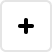
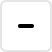
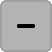
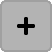
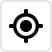
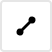
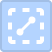
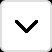
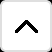
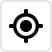
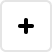
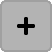
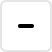
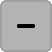
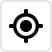
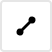
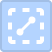
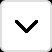
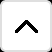
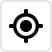

In [2]:
LetsPlot.setup_html()

In [3]:
# In the examples below, we will use the Mann–Whitney U test to calculate p-values
def get_p_value(df, cat_col, val_col, g1, g2):
    x = df.loc[df[cat_col] == g1, val_col]
    y = df.loc[df[cat_col] == g2, val_col]
    return mannwhitneyu(x, y, alternative="two-sided").pvalue

def get_p_values_data(df, *, cat_col, val_col, base_dy, step, limit_names=["xstart", "xend"]):
    from itertools import combinations
    categories = df[cat_col].unique().tolist()
    rows = []
    for i, (xmin, xmax) in enumerate(combinations(categories, 2)):
        y = base_dy + i * step
        p = get_p_value(df, cat_col, val_col, xmin, xmax)
        rows.append({"y": y, "p": p,
                     limit_names[0]: xmin,
                     limit_names[1]: xmax})
    return pd.DataFrame(rows)

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/refs/heads/master/data/mpg.csv")
print(df.shape)
df.head()

(234, 12)


,Unnamed: 0,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


## Plotting p-values

In [5]:
p_values_df = get_p_values_data(df, cat_col="drv", val_col="hwy", base_dy=47, step=4)
print(p_values_df.shape)
p_values_df

(3, 4)


,y,p,xstart,xend
0,47,9.041090e-28,f,4
1,51,5.955333e-11,f,r
2,55,4.104577e-02,4,r


In [6]:
p = ggplot(df, aes("drv", "hwy", fill="drv")) + \
    geom_boxplot(alpha=.25) + \
    geom_jitter(aes(color="drv"), height=0, shape=1, alpha=.25, show_legend=False, seed=42)

### Default Plot

In [7]:
p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="p"), data=p_values_df)

### Format Labels

#### With Parameter `label_format`

In [8]:
p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="p"), data=p_values_df, label_format=".2~g")

#### With `label_pvalue()` from `mizani`

In [9]:
from mizani.labels import label_pvalue

formatter = label_pvalue(add_p=True)
p_values_df = p_values_df.assign(label=lambda d: formatter(d["p"]))

p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="label"), data=p_values_df)

#### Custom Format

In [10]:
def stars_formatter(value):
    if value <= 0.001:
        return "***"
    if value <= 0.01:
        return "**"
    if value <= 0.05:
        return "*"
    return "ns"

p_values_df = p_values_df.assign(star=lambda d: d["p"].map(stars_formatter))

p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="star"), data=p_values_df)

## Brackets Between Dodged Subgroups Within Each Group

To draw brackets between dodged subgroups, prepare a dataframe that contains:

- a column with the main groups (the x-axis categories),

- two columns with the subgroup pair for each comparison (the two subgroups you computed a p-value for),

- the bracket level (`y`) and the label to display.

Then map the bracket layer’s `x` aesthetic to the main-group column, and pass the names of the subgroup-pair columns via `subgroup1` and `subgroup2`.

In [11]:
p_values_grouped_df = pd.concat([
    get_p_values_data(df[df["class"] == name], cat_col="cyl", val_col="hwy", base_dy=47, step=4, limit_names=["s1", "s2"]).assign(
        x=name,
        star=lambda d: d["p"].map(stars_formatter) if "p" in d else None
    )
    for group_id, name in enumerate(df["class"].unique())
]).reset_index(drop=True)

p_values_grouped_df.head()

,y,p,s1,s2,x,star
0,47.0,0.000025,4.0,6.0,compact,***
1,51.0,0.910367,4.0,5.0,compact,ns
2,55.0,0.030158,6.0,5.0,compact,*
3,47.0,0.030194,6.0,8.0,midsize,*
4,51.0,0.000009,6.0,4.0,midsize,***


In [12]:
(ggplot(df, aes("class", "hwy", fill=as_discrete("cyl")))
  + geom_boxplot(alpha=.25)
  + geom_point(aes(color=as_discrete("cyl")),
               position=position_jitterdodge(jitter_width=.2, jitter_height=0),
               shape=1, alpha=.25, show_legend=False, seed=42)
  + geom_bracket(aes(x="x", y="y", label="star"), data=p_values_grouped_df, subgroup1="s1", subgroup2="s2")
  + scale_brewer(["color", "fill"], palette="Accent", format="d")
  + ggsize(1000, 500))

Sometimes the library cannot reliably infer the exact ordering of groups and subgroups. To ensure brackets align with the correct boxes, specify `group_order` and `subgroup_order` in the same order as the groups and subgroups appear in the other layers of the plot.

In [13]:
(ggplot(df, aes("class", "hwy", fill=as_discrete("cyl")))
  + geom_boxplot(alpha=.25)
  + geom_point(aes(color=as_discrete("cyl")),
               position=position_jitterdodge(jitter_width=.2, jitter_height=0),
               shape=1, alpha=.25, show_legend=False, seed=42)
  + geom_bracket(aes(x="x", y="y", label="star"), data=p_values_grouped_df, subgroup1="s1", subgroup2="s2",
                 group_order=["compact", "midsize", "minivan", "subcompact", "suv", "pickup", "2seater"],
                 subgroup_order=[4, 6, 8, 5])
  + scale_brewer(["color", "fill"], palette="Accent", format="d")
  + ggsize(1000, 500))

## Upside Down Brackets

In [14]:
upside_down_p_values_df = get_p_values_data(df, cat_col="drv", val_col="hwy", base_dy=8, step=-4).assign(
    label=lambda d: formatter(d["p"])
)
print(upside_down_p_values_df.shape)
upside_down_p_values_df

(3, 5)


,y,p,xstart,xend,label
0,8,9.041090e-28,f,4,p<0.001
1,4,5.955333e-11,f,r,p<0.001
2,0,4.104577e-02,4,r,p=0.041


In [15]:
(p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="label"), data=upside_down_p_values_df,
                  tip_length_start=-5, tip_length_end=-5,  # Negative values to reverse the direction of the brackets
                  vjust=2))                                # Specify vjust to move the labels under the brackets

## Parameter `tip_length_unit`

In [16]:
(p + geom_bracket(aes(xmin="xstart", xmax="xend", y="y", label="label",
                      tip_length_start=[2, 2, 1],   # The lengths of the tips are selected taking into account that we know
                      tip_length_end=[18, 23, 2]),  # at what height the brackets are located and at what height the boxes end
                  data=p_values_df,
                  tip_length_unit='identity'))      # We can calculate the lengths of tips, since we chose 'identity' as the unit for their length

## Brackets for Grouping

Brackets can be used for more than just drawing p-values.
For example, they can be used to highlight cluster boundaries in the following scatter plot:

In [17]:
def get_continuous_brackets_data(df, cat_col, primary_val_col, secondary_val_col, step_mult):
    secondary_min, secondary_max = df[secondary_val_col].min(), df[secondary_val_col].max()
    step = (secondary_max - secondary_min) * step_mult
    base = secondary_max + step
    df = df.copy()
    df["drv"] = pd.Categorical(df["drv"], categories=["r", "4", "f"], ordered=True)
    df = df.sort_values(by="drv")
    return pd.merge(
        df.groupby(cat_col, observed=False)[primary_val_col].min().to_frame(f"{primary_val_col}_start").reset_index(),
        df.groupby(cat_col, observed=False)[primary_val_col].max().to_frame(f"{primary_val_col}_end").reset_index(),
        on="drv"
    ).reset_index().assign(**{f"{secondary_val_col}_level": lambda d: base + d["index"] * step})

(ggplot()
  + geom_point(aes("hwy", "cty", color="drv"), data=df, alpha=.25, show_legend=False)
  + geom_bracket(aes(xmin="hwy_start", xmax="hwy_end", y="cty_level", label="drv", color="drv"),
                 data=get_continuous_brackets_data(df, "drv", "hwy", "cty", .1))
  + geom_bracket(aes(x="hwy_level", ymin="cty_start", ymax="cty_end", label="drv", color="drv"),
                 data=get_continuous_brackets_data(df, "drv", "cty", "hwy", .05))
  + theme_minimal())